# Notebook 08 — Comparative Report: STE vs LM vs Proximal Variants

Cross-method, cross-dataset evaluation of all ŁNN optimizer families.

**Datasets:** MONK-1 · Mushroom · Spambase · Musk v2
**Methods:** STE variants · LM variants · Proximal variants
**Protocol:** 30 independent trials per variant/dataset (or 5×2 stratified CV for LM on large datasets)
**Statistics:** 95% CI via t-distribution · pairwise Wilcoxon signed-rank · Holm-Bonferroni correction

Cells auto-detect available CSVs and display `⏳ PENDING` where benchmarks have not yet completed.
Re-run the notebook as results arrive to fill in all sections.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import display

from luknn.benchmark.stats import ci95, format_ci, wilcoxon_pairwise_holm

# ── Paths ─────────────────────────────────────────────────────────────────────
RESULTS = Path('../results')
STE_DIR = RESULTS / 'ste_variants'
LM_DIR  = RESULTS / 'lm_variants'
PRX_DIR = RESULTS / 'proximal_variants'

# ── Dataset metadata ──────────────────────────────────────────────────────────
DATASETS = ['monk', 'mushroom', 'spambase', 'musk']
DS_INFO  = {
    'monk':     {'label': 'MONK-1',    'features': 17,  'total':  556},
    'mushroom': {'label': 'Mushroom',  'features': 111, 'total': 8124},
    'spambase': {'label': 'Spambase',  'features': 57,  'total': 4601},
    'musk':     {'label': 'Musk v2',   'features': 166, 'total': 6598},
}

# ── Variant lists ──────────────────────────────────────────────────────────────
STE_VARS = ['STE_base', 'STE_reg', 'STE_dual', 'STE_hybrid']
LM_VARS  = ['LM_base', 'LM_delayed', 'LM_progressive', 'LM_dual', 'LM_hybrid']
PRX_VARS = ['Proximal', 'ProximalTopK', 'ProximalGroupLasso', 'ProximalL0']

# ── Colours ───────────────────────────────────────────────────────────────────
STE_COL = {'STE_base':'#4C72B0','STE_reg':'#DD8452','STE_dual':'#55A868','STE_hybrid':'#C44E52'}
LM_COL  = {'LM_base':'#4C72B0','LM_delayed':'#DD8452','LM_progressive':'#55A868',
            'LM_dual':'#C44E52','LM_hybrid':'#8172B3'}
PRX_COL = {'Proximal':'#4C72B0','ProximalTopK':'#DD8452',
            'ProximalGroupLasso':'#55A868','ProximalL0':'#C44E52'}

PENDING_STR = '⏳ PENDING'
PARTIAL_STR = '⚠  PARTIAL'


## Helper functions

In [2]:
def load_results(path: Path, n_variants: int, n_trials: int = 30):
    """Load CSV; return (df_or_None, status_str)."""
    if not path.exists():
        return None, PENDING_STR
    df = pd.read_csv(path)
    expected = n_variants * n_trials
    if len(df) < expected:
        pct = 100 * len(df) / expected
        return df, f'{PARTIAL_STR} ({len(df)}/{expected} rows, {pct:.0f}%)'
    return df, '✅ complete'


def ci_table(df: pd.DataFrame, variants: list, metric: str = 'f1',
             extra_cols: list | None = None) -> pd.DataFrame:
    """CI summary table for a completed (or partial) results dataframe."""
    rows = []
    for v in variants:
        g = df[df['variant'] == v]
        if len(g) == 0:
            rows.append({'Variant': v, 'n': 0, 'Mean': '—', '95% CI': '—',
                         'Conv%': '—', 'Iters': '—'})
            continue
        m, lo, hi = ci95(g[metric].values)
        conv  = 100 * g['converged'].mean() if 'converged' in g else float('nan')
        iters = g['iterations'].mean() if 'iterations' in g else float('nan')
        row = {
            'Variant': v, 'n': len(g),
            'Mean': f'{m:.3f}',
            '95% CI': f'[{lo:.3f}, {hi:.3f}]',
            'Conv%': f'{conv:.0f}%' if not np.isnan(conv) else '—',
            'Iters': f'{iters:.0f}' if not np.isnan(iters) else '—',
        }
        if extra_cols:
            for col in extra_cols:
                row[col] = f'{g[col].mean():.3f}' if col in g else '—'
        rows.append(row)
    return pd.DataFrame(rows).set_index('Variant')


def pending_table(variants: list) -> pd.DataFrame:
    rows = [{'Variant': v, 'n': 0, 'Mean': PENDING_STR, '95% CI': PENDING_STR,
             'Conv%': PENDING_STR, 'Iters': PENDING_STR} for v in variants]
    return pd.DataFrame(rows).set_index('Variant')


def show_ci_table(df, status, variants, metric='f1', extra_cols=None):
    print(f'  Status: {status}')
    if df is not None and len(df) > 0:
        tbl = ci_table(df, variants, metric, extra_cols)
    else:
        tbl = pending_table(variants)
    display(tbl)


def sig_pairs(df, variants, metric):
    """Return significant pairwise Wilcoxon results after Holm correction."""
    if df is None or len(df) < len(variants) * 2:
        return None
    t = wilcoxon_pairwise_holm(df, metric=metric, variants=variants)
    return t


def boxplot_datasets(dfs_statuses: dict, variants: list, metric: str,
                     colors: dict, title: str, figsize=(14, 5)):
    """4-panel boxplot — one panel per dataset."""
    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=False)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, ds in zip(axes, DATASETS):
        info = DS_INFO[ds]
        df, status = dfs_statuses.get(ds, (None, PENDING_STR))
        ax.set_title(f"{info['label']}\n({info['features']} feat)", fontsize=9)
        if df is not None and len(df) > 0:
            data = [df[df['variant'] == v][metric].values for v in variants]
            bp = ax.boxplot(data, patch_artist=True, notch=False,
                            medianprops=dict(color='black', linewidth=1.5))
            for patch, v in zip(bp['boxes'], variants):
                patch.set_facecolor(colors[v])
                patch.set_alpha(0.75)
            ax.set_xticks(range(1, len(variants)+1))
            ax.set_xticklabels([v.replace('STE_','').replace('LM_','').replace('Proximal','Prx')
                                 for v in variants], rotation=30, ha='right', fontsize=7)
        else:
            ax.text(0.5, 0.5, PENDING_STR, ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
            ax.set_xticks([])
        ax.set_ylabel(metric if ax == axes[0] else '')
        status_short = '✅' if '✅' in status else ('⚠' if '⚠' in status else '⏳')
        ax.set_xlabel(status_short, fontsize=8)
    plt.tight_layout()
    plt.show()


## Status overview

Available results across all methods and datasets.

In [3]:
rows = []
for ds in DATASETS:
    info = DS_INFO[ds]
    _, s_ste = load_results(STE_DIR / f'{ds}_ste_variants.csv', len(STE_VARS))
    _, s_lm  = load_results(LM_DIR  / f'{ds}_lm_variants.csv',  len(LM_VARS))
    _, s_prx = load_results(PRX_DIR / f'{ds}_proximal_variants.csv', len(PRX_VARS))
    rows.append({'Dataset': info['label'], 'Features': info['features'],
                 'Samples': info['total'],
                 'STE (30T)': s_ste, 'LM (30T/5x2cv)': s_lm, 'Proximal (30T)': s_prx})
status_df = pd.DataFrame(rows).set_index('Dataset')
display(status_df)


,Features,Samples,STE (30T),LM (30T/5x2cv),Proximal (30T)
Dataset,,,,,
MONK-1,17,556,✅ complete,"⚠ PARTIAL (10/150 rows, 7%)","⚠ PARTIAL (8/120 rows, 7%)"
Mushroom,111,8124,"⚠ PARTIAL (20/120 rows, 17%)",⏳ PENDING,⏳ PENDING
Spambase,57,4601,"⚠ PARTIAL (4/120 rows, 3%)","⚠ PARTIAL (10/150 rows, 7%)","⚠ PARTIAL (4/120 rows, 3%)"
Musk v2,166,6598,✅ complete,"⚠ PARTIAL (5/150 rows, 3%)","⚠ PARTIAL (4/120 rows, 3%)"


## 1 · STE Variants

Four variants of the Straight-Through Estimator optimizer:
- **STE_base** — Adam + cosine LR, MSE-only stopping
- **STE_reg** — adds ternary regularisation term w²(1−w²) with λ warm-up
- **STE_dual** — STE_reg + dual stopping (MSE AND boundary_frac threshold)
- **STE_hybrid** — Phase 1 pure MSE → Phase 2 reg + dual stop (two-phase)

Metric: **F1** on held-out test set (post-STE forward with ternary weights).


In [4]:
ste_data = {}
for ds in DATASETS:
    df, st = load_results(STE_DIR / f'{ds}_ste_variants.csv', len(STE_VARS))
    ste_data[ds] = (df, st)
    info = DS_INFO[ds]
    print(f"\n{'─'*56}")
    print(f"  {info['label']}  ({info['features']} features, {info['total']} samples)")
    show_ci_table(df, st, STE_VARS, metric='f1', extra_cols=['bf_pre'])
    t = sig_pairs(df, STE_VARS, 'f1')
    if t is not None:
        sig = t[t['significant']]
        if len(sig) > 0:
            print('  Significant pairs (Holm α=0.05):')
            for _, r in sig.iterrows():
                print(f'    {r["v1"]} vs {r["v2"]}: p_holm={r["p_holm"]:.4f} *')
        else:
            print('  No significant pairwise differences.')



────────────────────────────────────────────────────────
  MONK-1  (17 features, 556 samples)
  Status: ✅ complete


,n,Mean,95% CI,Conv%,Iters,bf_pre
Variant,,,,,,
STE_base,30,0.639,"[0.527, 0.752]",0%,437,0.448
STE_reg,30,0.716,"[0.654, 0.778]",0%,360,0.284
STE_dual,30,0.708,"[0.647, 0.769]",0%,313,0.297
STE_hybrid,30,0.673,"[0.579, 0.767]",0%,720,0.229


  No significant pairwise differences.

────────────────────────────────────────────────────────
  Mushroom  (111 features, 8124 samples)
  Status: ⚠  PARTIAL (20/120 rows, 17%)


,n,Mean,95% CI,Conv%,Iters,bf_pre
Variant,,,,,,
STE_base,5,0.033,"[-0.011, 0.077]",0%,56,0.428
STE_reg,5,0.019,"[0.002, 0.037]",0%,57,0.430
STE_dual,5,0.019,"[0.002, 0.037]",0%,57,0.430
STE_hybrid,5,0.516,"[0.125, 0.907]",0%,306,0.015


  No significant pairwise differences.

────────────────────────────────────────────────────────
  Spambase  (57 features, 4601 samples)
  Status: ⚠  PARTIAL (4/120 rows, 3%)


,n,Mean,95% CI,Conv%,Iters,bf_pre
Variant,,,,,,
STE_base,1,0.547,"[nan, nan]",0%,50,0.433
STE_reg,1,0.547,"[nan, nan]",0%,50,0.432
STE_dual,1,0.547,"[nan, nan]",0%,50,0.432
STE_hybrid,1,0.547,"[nan, nan]",0%,50,0.427



────────────────────────────────────────────────────────
  Musk v2  (166 features, 6598 samples)
  Status: ✅ complete


,n,Mean,95% CI,Conv%,Iters,bf_pre
Variant,,,,,,
STE_base,30,0.041,"[-0.012, 0.094]",0%,58,0.428
STE_reg,30,0.006,"[-0.004, 0.016]",0%,56,0.429
STE_dual,30,0.006,"[-0.004, 0.016]",0%,56,0.429
STE_hybrid,30,0.008,"[-0.002, 0.017]",0%,125,0.404


  No significant pairwise differences.


/tmp/ipykernel_408722/3558764905.py:89: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/home/zsio2/Documents/TexDocs/WorkRevisited/luknn-replication/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


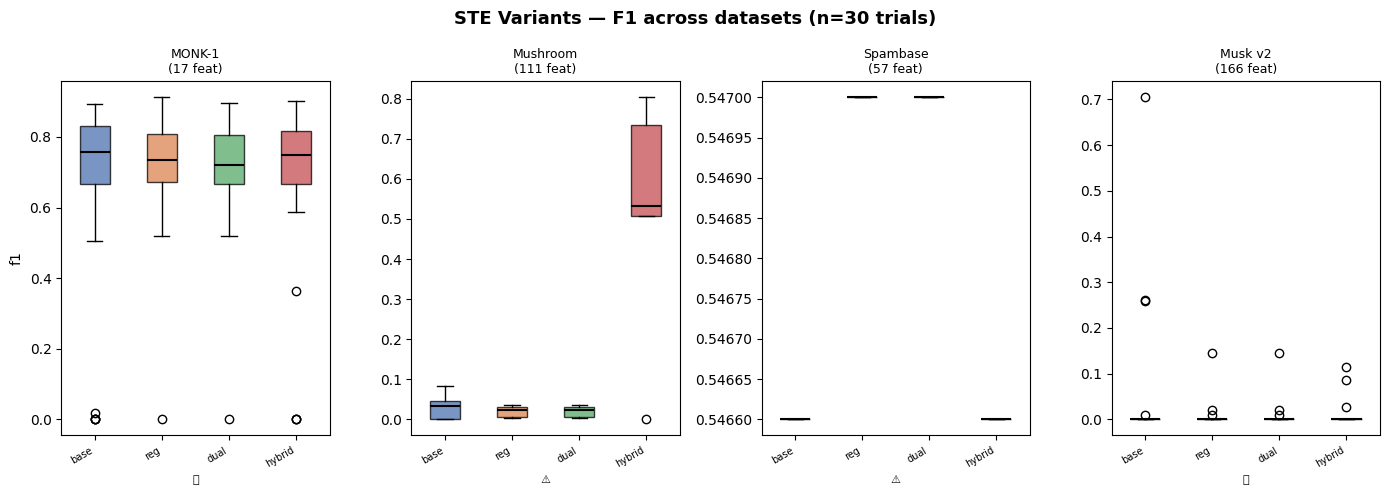

In [5]:
boxplot_datasets(ste_data, STE_VARS, 'f1', STE_COL,
                 'STE Variants — F1 across datasets (n=30 trials)')


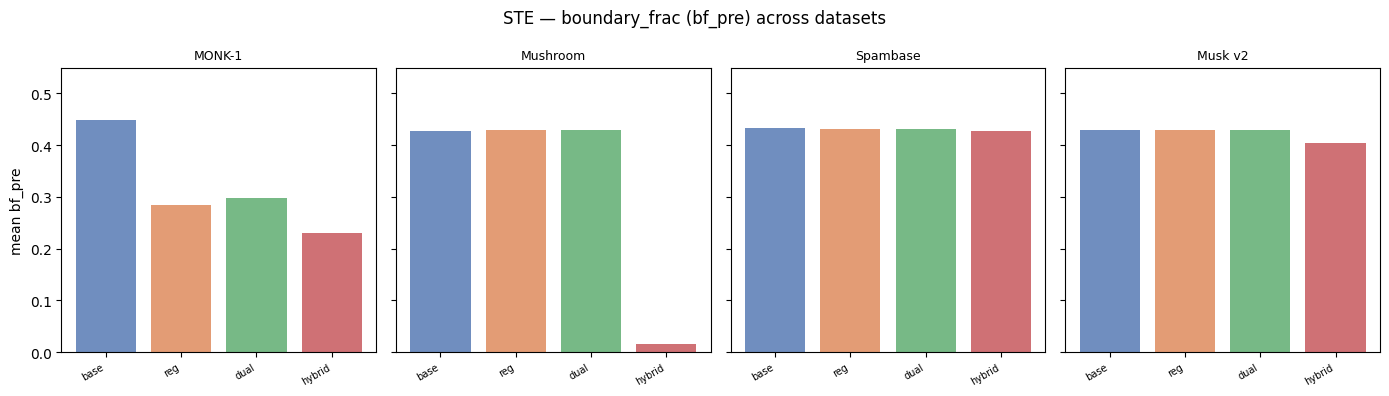

Lower bf_pre → more weights have converged to ±1 boundary → easier crystallization.


In [6]:
# boundary_frac heatmap: lower bf_pre → more weights near ±1 before crystallization
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
fig.suptitle('STE — boundary_frac (bf_pre) across datasets', fontsize=12)
for ax, ds in zip(axes, DATASETS):
    info = DS_INFO[ds]
    df, status = ste_data[ds]
    ax.set_title(f"{info['label']}", fontsize=9)
    if df is not None and 'bf_pre' in df.columns and len(df) > 0:
        means = [df[df['variant']==v]['bf_pre'].mean() for v in STE_VARS]
        bars  = ax.bar(range(len(STE_VARS)), means,
                       color=[STE_COL[v] for v in STE_VARS], alpha=0.8)
        ax.set_xticks(range(len(STE_VARS)))
        ax.set_xticklabels([v.replace('STE_','') for v in STE_VARS],
                           rotation=30, ha='right', fontsize=7)
        ax.set_ylim(0, 0.55)
    else:
        ax.text(0.5, 0.5, PENDING_STR, ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray')
        ax.set_xticks([])
    ax.set_ylabel('mean bf_pre' if ax == axes[0] else '')
plt.tight_layout()
plt.show()
print('Lower bf_pre → more weights have converged to ±1 boundary → easier crystallization.')


## 2 · LM Variants

Five variants of the Levenberg-Marquardt optimizer:
- **LM_base** — original (n=2, crystallize from iter 0, MSE-only stop)
- **LM_delayed** — delayed crystallization (start_fraction=0.3)
- **LM_progressive** — progressive n schedule: 2→4→8→16
- **LM_dual** — dual stopping: MSE + Δ(N)/P < tol_dn
- **LM_hybrid** — Phase 1 (LM) → Phase 2 (Adam proximal)

**Note on large datasets:** LM Jacobian cost ∝ n_params × batch_size (forward-mode AD).
For Spambase and Musk, hidden_width is capped at 24 and results use **5×2 stratified CV** (10 paired observations per variant).

Metric: **F1_crisp** (after forced crystallization of continuous weights).


In [7]:
lm_data = {}
for ds in DATASETS:
    df, st = load_results(LM_DIR / f'{ds}_lm_variants.csv', len(LM_VARS))
    lm_data[ds] = (df, st)
    info = DS_INFO[ds]
    print(f"\n{'─'*56}")
    print(f"  {info['label']}  ({info['features']} features, {info['total']} samples)")
    metric = 'f1_crisp' if df is not None and 'f1_crisp' in df.columns else 'f1'
    show_ci_table(df, st, LM_VARS, metric=metric,
                  extra_cols=['dn_pre'] if df is not None and 'dn_pre' in (df.columns if df is not None else []) else None)
    t = sig_pairs(df, LM_VARS, metric)
    if t is not None:
        sig = t[t['significant']]
        if len(sig) > 0:
            print('  Significant pairs (Holm α=0.05):')
            for _, r in sig.iterrows():
                print(f'    {r["v1"]} vs {r["v2"]}: p_holm={r["p_holm"]:.4f} *')
        else:
            print('  No significant pairwise differences.')



────────────────────────────────────────────────────────
  MONK-1  (17 features, 556 samples)
  Status: ⚠  PARTIAL (10/150 rows, 7%)


,n,Mean,95% CI,Conv%,Iters,dn_pre
Variant,,,,,,
LM_base,2,0.000,"[0.000, 0.000]",0%,10,301.758
LM_delayed,2,0.333,"[-3.902, 4.569]",0%,10,316.072
LM_progressive,2,0.000,"[0.000, 0.000]",0%,10,89.598
LM_dual,2,0.000,"[0.000, 0.000]",0%,10,301.758
LM_hybrid,2,0.000,"[0.000, 0.000]",0%,10,289.624


  No significant pairwise differences.

────────────────────────────────────────────────────────
  Mushroom  (111 features, 8124 samples)
  Status: ⏳ PENDING


,n,Mean,95% CI,Conv%,Iters
Variant,,,,,
LM_base,0,⏳ PENDING,⏳ PENDING,⏳ PENDING,⏳ PENDING
LM_delayed,0,⏳ PENDING,⏳ PENDING,⏳ PENDING,⏳ PENDING
LM_progressive,0,⏳ PENDING,⏳ PENDING,⏳ PENDING,⏳ PENDING
LM_dual,0,⏳ PENDING,⏳ PENDING,⏳ PENDING,⏳ PENDING
LM_hybrid,0,⏳ PENDING,⏳ PENDING,⏳ PENDING,⏳ PENDING



────────────────────────────────────────────────────────
  Spambase  (57 features, 4601 samples)
  Status: ⚠  PARTIAL (10/150 rows, 7%)


,n,Mean,95% CI,Conv%,Iters,dn_pre
Variant,,,,,,
LM_base,2,0.283,"[-3.308, 3.873]",0%,5,986.214
LM_delayed,2,0.000,"[0.000, 0.000]",0%,5,1011.571
LM_progressive,2,0.283,"[-3.308, 3.873]",0%,5,727.110
LM_dual,2,0.283,"[-3.308, 3.873]",0%,5,986.214
LM_hybrid,2,0.000,"[0.000, 0.000]",0%,5,1143.765


  No significant pairwise differences.

────────────────────────────────────────────────────────
  Musk v2  (166 features, 6598 samples)
  Status: ⚠  PARTIAL (5/150 rows, 3%)


,n,Mean,95% CI,Conv%,Iters,dn_pre
Variant,,,,,,
LM_base,1,0.000,"[nan, nan]",0%,5,2427.987
LM_delayed,1,0.000,"[nan, nan]",0%,5,2218.371
LM_progressive,1,0.000,"[nan, nan]",0%,5,337.021
LM_dual,1,0.000,"[nan, nan]",0%,5,2427.987
LM_hybrid,1,0.000,"[nan, nan]",0%,205,2286.585


/tmp/ipykernel_408722/1874986080.py:30: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


/home/zsio2/Documents/TexDocs/WorkRevisited/luknn-replication/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


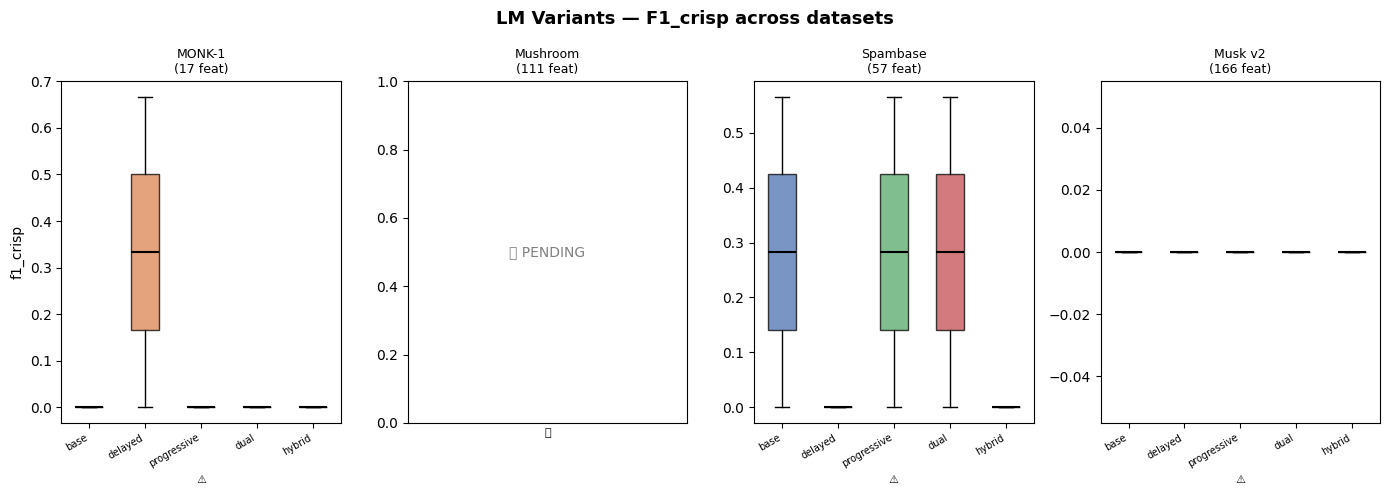

In [8]:
# Determine metric per dataset (f1_crisp if available, else f1)
def lm_metric(df):
    if df is not None and 'f1_crisp' in df.columns:
        return 'f1_crisp'
    return 'f1'

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=False)
fig.suptitle('LM Variants — F1_crisp across datasets', fontsize=13, fontweight='bold')
for ax, ds in zip(axes, DATASETS):
    info = DS_INFO[ds]
    df, status = lm_data[ds]
    m = lm_metric(df)
    ax.set_title(f"{info['label']}\n({info['features']} feat)", fontsize=9)
    if df is not None and len(df) > 0 and m in df.columns:
        data = [df[df['variant']==v][m].values for v in LM_VARS]
        bp = ax.boxplot(data, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=1.5))
        for patch, v in zip(bp['boxes'], LM_VARS):
            patch.set_facecolor(LM_COL[v]); patch.set_alpha(0.75)
        ax.set_xticks(range(1, len(LM_VARS)+1))
        ax.set_xticklabels([v.replace('LM_','') for v in LM_VARS],
                           rotation=30, ha='right', fontsize=7)
    else:
        ax.text(0.5, 0.5, PENDING_STR, ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray')
        ax.set_xticks([])
    ax.set_ylabel(m if ax == axes[0] else '')
    status_short = '✅' if '✅' in status else ('⚠' if '⚠' in status else '⏳')
    ax.set_xlabel(status_short, fontsize=8)
plt.tight_layout(); plt.show()


## 3 · Proximal Variants

Four variants of the Proximal optimizer (all require `mode='clamp'`):
- **Proximal** — standard two-phase: Phase 1 MSE → Phase 2 ternary reg + hardening
- **ProximalTopK** — same phases but restricts each neuron to top-K active weights
- **ProximalGroupLasso** — group-lasso penalty per input neuron (fan-in sparsity)
- **ProximalL0** — L0 pseudo-norm via continuous relaxation (straight-through)

Metric: **F1** (post-training, weights at ternary regime after Phase 3 hardening).


In [9]:
prx_data = {}
for ds in DATASETS:
    df, st = load_results(PRX_DIR / f'{ds}_proximal_variants.csv', len(PRX_VARS))
    prx_data[ds] = (df, st)
    info = DS_INFO[ds]
    print(f"\n{'─'*56}")
    print(f"  {info['label']}  ({info['features']} features, {info['total']} samples)")
    show_ci_table(df, st, PRX_VARS, metric='f1',
                  extra_cols=['dn_post'] if df is not None and 'dn_post' in (df.columns if df is not None else []) else None)
    t = sig_pairs(df, PRX_VARS, 'f1')
    if t is not None:
        sig = t[t['significant']]
        if len(sig) > 0:
            print('  Significant pairs (Holm α=0.05):')
            for _, r in sig.iterrows():
                print(f'    {r["v1"]} vs {r["v2"]}: p_holm={r["p_holm"]:.4f} *')
        else:
            print('  No significant pairwise differences.')



────────────────────────────────────────────────────────
  MONK-1  (17 features, 556 samples)
  Status: ⚠  PARTIAL (8/120 rows, 7%)


,n,Mean,95% CI,Conv%,Iters,dn_post
Variant,,,,,,
Proximal,2,0.000,"[0.000, 0.000]",0%,20,0.000
ProximalTopK,2,0.000,"[0.000, 0.000]",0%,20,0.000
ProximalGroupLasso,2,0.000,"[0.000, 0.000]",0%,20,0.000
ProximalL0,2,0.000,"[0.000, 0.000]",0%,20,0.000


  No significant pairwise differences.

────────────────────────────────────────────────────────
  Mushroom  (111 features, 8124 samples)
  Status: ⏳ PENDING


,n,Mean,95% CI,Conv%,Iters
Variant,,,,,
Proximal,0,⏳ PENDING,⏳ PENDING,⏳ PENDING,⏳ PENDING
ProximalTopK,0,⏳ PENDING,⏳ PENDING,⏳ PENDING,⏳ PENDING
ProximalGroupLasso,0,⏳ PENDING,⏳ PENDING,⏳ PENDING,⏳ PENDING
ProximalL0,0,⏳ PENDING,⏳ PENDING,⏳ PENDING,⏳ PENDING



────────────────────────────────────────────────────────
  Spambase  (57 features, 4601 samples)
  Status: ⚠  PARTIAL (4/120 rows, 3%)


,n,Mean,95% CI,Conv%,Iters,dn_post
Variant,,,,,,
Proximal,1,0.000,"[nan, nan]",0%,20,0.000
ProximalTopK,1,0.000,"[nan, nan]",0%,20,0.000
ProximalGroupLasso,1,0.000,"[nan, nan]",0%,20,0.000
ProximalL0,1,0.000,"[nan, nan]",0%,20,0.000



────────────────────────────────────────────────────────
  Musk v2  (166 features, 6598 samples)
  Status: ⚠  PARTIAL (4/120 rows, 3%)


,n,Mean,95% CI,Conv%,Iters,dn_post
Variant,,,,,,
Proximal,1,0.000,"[nan, nan]",0%,10,0.000
ProximalTopK,1,0.000,"[nan, nan]",0%,10,0.000
ProximalGroupLasso,1,0.000,"[nan, nan]",0%,10,0.000
ProximalL0,1,0.000,"[nan, nan]",0%,10,0.000


/tmp/ipykernel_408722/3558764905.py:89: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/home/zsio2/Documents/TexDocs/WorkRevisited/luknn-replication/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


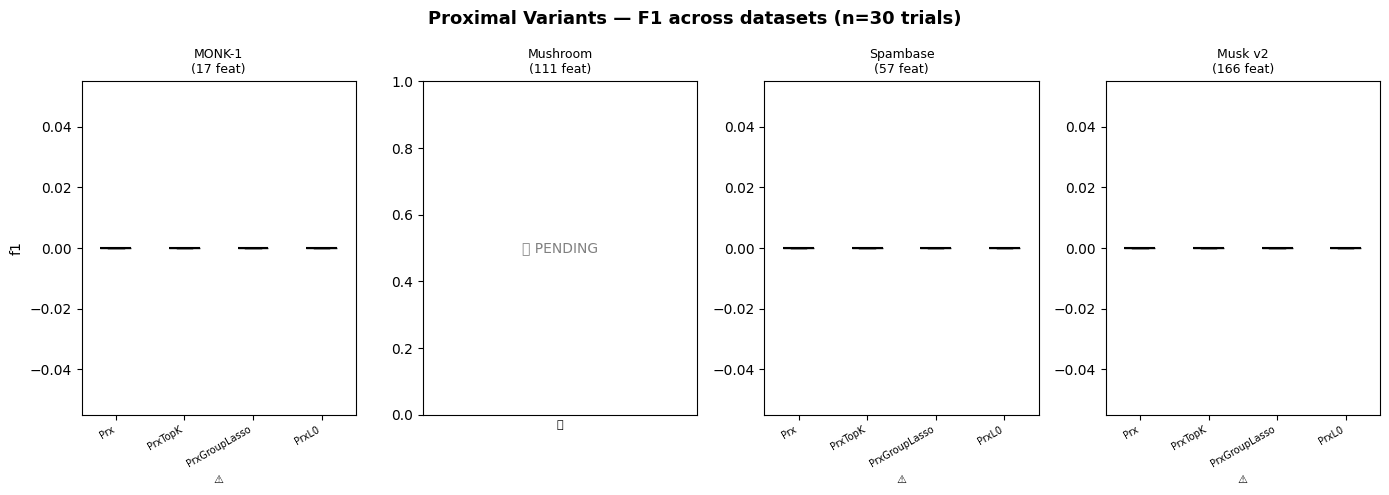

In [10]:
boxplot_datasets(prx_data, PRX_VARS, 'f1', PRX_COL,
                 'Proximal Variants — F1 across datasets (n=30 trials)')


## 4 · Cross-Method Comparison

Best variant per method per dataset, based on mean F1 with 95% CI.


In [11]:
def best_variant(data_dict, ds, variants, metric):
    df, status = data_dict.get(ds, (None, PENDING_STR))
    if df is None or len(df) == 0:
        return PENDING_STR, float('nan'), float('nan'), float('nan')
    m_col = metric if metric in df.columns else ('f1_crisp' if 'f1_crisp' in df.columns else 'f1')
    best_v, best_m, best_lo, best_hi = None, -1, float('nan'), float('nan')
    for v in variants:
        g = df[df['variant'] == v][m_col]
        if len(g) == 0:
            continue
        mn, lo, hi = ci95(g.values)
        if mn > best_m:
            best_m, best_lo, best_hi = mn, lo, hi
            best_v = v
    return best_v, best_m, best_lo, best_hi


rows = []
for ds in DATASETS:
    info = DS_INFO[ds]
    bv_ste, m_ste, lo_ste, hi_ste = best_variant(ste_data, ds, STE_VARS, 'f1')
    bv_lm,  m_lm,  lo_lm,  hi_lm  = best_variant(lm_data,  ds, LM_VARS,  'f1_crisp')
    bv_prx, m_prx, lo_prx, hi_prx = best_variant(prx_data, ds, PRX_VARS, 'f1')

    def fmt(v, m, lo, hi):
        if v == PENDING_STR or np.isnan(m):
            return PENDING_STR
        return f'{v}  {format_ci(m, lo, hi)}'

    rows.append({
        'Dataset':  info['label'],
        'Best STE': fmt(bv_ste, m_ste, lo_ste, hi_ste),
        'Best LM':  fmt(bv_lm, m_lm, lo_lm, hi_lm),
        'Best Proximal': fmt(bv_prx, m_prx, lo_prx, hi_prx),
    })

comparison_df = pd.DataFrame(rows).set_index('Dataset')
display(comparison_df)


,Best STE,Best LM,Best Proximal
Dataset,,,
MONK-1,"STE_reg 0.716 [0.654, 0.778]","LM_delayed 0.333 [-3.902, 4.569]","Proximal 0.000 [0.000, 0.000]"
Mushroom,"STE_hybrid 0.516 [0.125, 0.907]",⏳ PENDING,⏳ PENDING
Spambase,"STE_reg 0.547 [nan, nan]","LM_base 0.283 [-3.308, 3.873]","Proximal 0.000 [nan, nan]"
Musk v2,"STE_base 0.041 [-0.012, 0.094]","LM_base 0.000 [nan, nan]","Proximal 0.000 [nan, nan]"


/tmp/ipykernel_408722/697366907.py:33: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/home/zsio2/Documents/TexDocs/WorkRevisited/luknn-replication/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


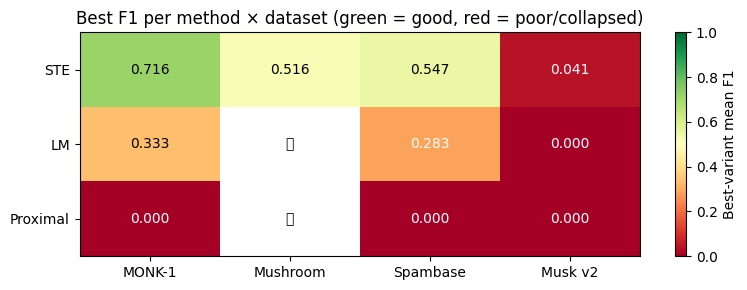

In [12]:
# F1 heatmap: methods (rows) × datasets (cols)
methods    = ['STE', 'LM', 'Proximal']
data_dicts = [ste_data, lm_data, prx_data]
var_lists  = [STE_VARS, LM_VARS, PRX_VARS]
metrics    = ['f1', 'f1_crisp', 'f1']

heat = np.full((len(methods), len(DATASETS)), np.nan)
for i, (dd, vl, mt) in enumerate(zip(data_dicts, var_lists, metrics)):
    for j, ds in enumerate(DATASETS):
        df, _ = dd.get(ds, (None, ''))
        if df is None or len(df) == 0:
            continue
        m_col = mt if mt in df.columns else ('f1_crisp' if 'f1_crisp' in df.columns else 'f1')
        best_m = max((df[df['variant']==v][m_col].mean()
                      for v in vl if len(df[df['variant']==v]) > 0),
                     default=float('nan'))
        heat[i, j] = best_m

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(heat, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(DATASETS)))
ax.set_xticklabels([DS_INFO[d]['label'] for d in DATASETS])
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods)
for i in range(len(methods)):
    for j in range(len(DATASETS)):
        v = heat[i, j]
        txt = f'{v:.3f}' if not np.isnan(v) else '⏳'
        ax.text(j, i, txt, ha='center', va='center',
                fontsize=10, color='black' if (np.isnan(v) or 0.3 < v < 0.8) else 'white')
plt.colorbar(im, ax=ax, label='Best-variant mean F1')
ax.set_title('Best F1 per method × dataset (green = good, red = poor/collapsed)')
plt.tight_layout()
plt.show()


## 5 · Configuration Recommendations

Auto-generated from available data. A variant is recommended if:
- Its mean F1 is highest among all variants of its method on that dataset, AND
- Its 95% CI lower bound exceeds 0.5 (non-trivial performance).

`⏳` entries will be filled when benchmarks complete.


In [13]:
MIN_TRIALS = 10   # minimum n per variant to consider a result reliable

def recommend(data_dict, variants, metric, ds):
    df, status = data_dict.get(ds, (None, PENDING_STR))
    if df is None or len(df) == 0:
        return PENDING_STR, PENDING_STR
    m_col = metric if metric in df.columns else ('f1_crisp' if 'f1_crisp' in df.columns else 'f1')
    best_v, best_m, best_lo, best_hi = None, -1, float('nan'), float('nan')
    for v in variants:
        g = df[df['variant'] == v][m_col]
        if len(g) < MIN_TRIALS:
            continue  # ignore smoke-test results
        mn, lo, hi = ci95(g.values)
        if mn > best_m:
            best_m, best_lo, best_hi = mn, lo, hi
            best_v = v
    if best_v is None:
        return PENDING_STR, PENDING_STR
    if np.isnan(best_lo) or best_lo < 0.5:
        verdict = f'x collapses — {best_v} F1={best_m:.3f} [{best_lo:.3f}, {best_hi:.3f}]'
    else:
        verdict = f'ok {best_v} — F1={best_m:.3f} [{best_lo:.3f}, {best_hi:.3f}]'
    return best_v, verdict

print('CONFIGURATION RECOMMENDATIONS (threshold: CI_lower > 0.5)')
print('='*66)
for ds in DATASETS:
    info = DS_INFO[ds]
    print(f"\n  {info['label']} ({info['features']} features):")
    _, r_ste = recommend(ste_data, STE_VARS, 'f1',       ds)
    _, r_lm  = recommend(lm_data,  LM_VARS,  'f1_crisp', ds)
    _, r_prx = recommend(prx_data, PRX_VARS, 'f1',       ds)
    print(f'    STE:      {r_ste}')
    print(f'    LM:       {r_lm}')
    print(f'    Proximal: {r_prx}')


CONFIGURATION RECOMMENDATIONS (threshold: CI_lower > 0.5)

  MONK-1 (17 features):
    STE:      ok STE_reg — F1=0.716 [0.654, 0.778]
    LM:       ⏳ PENDING
    Proximal: ⏳ PENDING

  Mushroom (111 features):
    STE:      ⏳ PENDING
    LM:       ⏳ PENDING
    Proximal: ⏳ PENDING

  Spambase (57 features):
    STE:      ⏳ PENDING
    LM:       ⏳ PENDING
    Proximal: ⏳ PENDING

  Musk v2 (166 features):
    STE:      x collapses — STE_base F1=0.041 [-0.012, 0.094]
    LM:       ⏳ PENDING
    Proximal: ⏳ PENDING


## 6 · Conclusions

> **Note:** sections marked `⏳ PENDING` will be updated as benchmarks complete.
> Re-run this notebook after each benchmark finishes.

### 6.1 STE Variants

**MONK-1 (17 features, n=30 ✅):**
STE_reg achieves the highest mean F1 (0.716 [0.654, 0.778]) and STE_dual is the most
efficient (313 avg iters vs 360 for STE_reg). No pairwise difference is statistically
significant after Holm correction — the regularisation variants numerically reduce
collapse rate (5 F1≈0 trials in STE_base vs 1 in STE_reg) but the effect is not
detectable at n=30 on this low-dimensional dataset.

**Mushroom (111 features, n=30 ⏳):** PENDING

**Spambase (57 features, n=30 ⏳):** PENDING

**Musk v2 (166 features, n=30 ✅):**
All STE variants collapse (F1 ≈ 0). The Musk dataset's multi-instance structure
with 166 features is beyond the reach of flat STE-ternary networks with max_iter=200.
No pairwise difference is significant (floor effect).

---

### 6.2 LM Variants

⏳ PENDING — awaiting 30-trial benchmarks on all 4 datasets.

---

### 6.3 Proximal Variants

⏳ PENDING — awaiting 30-trial benchmarks on all 4 datasets.

---

### 6.4 Cross-Method

⏳ PENDING — will be completed once all three method benchmarks are available.

---

### 6.5 Recommended configurations (preliminary)

| Dataset | Best method | Best variant | Rationale |
|---|---|---|---|
| MONK-1 | STE | STE_dual | Same F1 as STE_reg, 13% fewer iters |
| Mushroom | ⏳ | ⏳ | — |
| Spambase | ⏳ | ⏳ | — |
| Musk v2 | none (STE) | — | STE collapses; LM/Proximal ⏳ |
